# Perspektiva - měření výšky v obraze
Cvičení je zaměřené na vyzkoušení si měření výšky objektů v obraze pomocí úběžníků a úběžnic (viz přednáška [Perspektiva a geometrie obrazu](../../../lectures/files/bi-svz-05-perspektiva-obrazu.pdf)). 

Z pohledu zpracování obrazu se jedná o hranovou detekci pomocí [Cannyho detektoru](https://en.wikipedia.org/wiki/Canny_edge_detector) následovanou [Houghovou transformací](https://en.wikipedia.org/wiki/Hough_transform), která nalezené hrany aproximuje přímkami. K zisku úběžníků a úběžnic z nalezených přímek je využit algoritmus [RANSAC](https://en.wikipedia.org/wiki/Random_sample_consensus) převzatý z [githubu](https://github.com/chsasank/Image-Rectification). Ten vyhledá nejvhodnější přímky jdoucí stejným směrem postupně do všech tří úběžníků.

Následně je využit vlastní algoritmus pro odhad výšky objektů `HeightEstimator` na základě měření známých rozměrů v obraze. **Měřit je nutné vždy od spojnice roviny horizontální s rovinou vertikální ve směru osy z.**

Na obrázku příkladu je znázorněno měření dvou referenčních vzdáleností. Dále je na něm znázorněna reálná výška dvou objektů - osob. Měření se zadává vždy v pořadí: bod Tx (top point) a následně bod Bx (bottom point).

![](images/miry.png)

### Import knihoven a konfigurace

In [2]:
import os
import io

import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings

from improutils import *
from skimage import feature, color, transform

warnings.filterwarnings('ignore')
%matplotlib inline
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

%run height-estimator.ipynb

### Pomocné funkce
Seznam funkcí pro přehlednost:

- [`cv2.cvtColor`](https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html#ga397ae87e1288a81d2363b61574eb8cab)


- [`Funkce a modely pro výpočty odhadu výšky`](../svz.ipynb#height_estimation_functions)


- [`show_images`](https://gitlab.fit.cvut.cz/bi-svz/improutils_package/blob/master/improutils/visualisation/visualisation.py#L55)

---

### Úkol
Vytvořte umělou scénu sestávající se ze dvou šachovnic na sebe kolmých. Do scény umístěte objekt, jehož výšku chcete změřit pomocí kamery.

Kamerou získejte obrázek a uložte ho. Následně změřte ručně v obraze dvě a více vzdáleností ve směru osy z (čím více vzdáleností, tím přesnější výsledek). Můžete využít znalosti toho, že jedno pole mřížky má stranu dlouhou 3 cm. Stejné vzdálenosti změřte i v reálné scéně.

Pomocí algoritmu získejte úběžnice a úběžníky. Pomocí nich spočtěte reálnou výšku objektu v obraze.

#### 1) Vytvořte umělou scénu a změřte reálné rozměry v ose z
Umělá scéna by měla vypadat nějak podobně jako na obrázku. 

<img src="images/artificial_scene_chess.png" width="50%">

#### 2) Získejte obrázek umělé scény kamerou Basler a zobrazte
Využijte jakýkoli nástroj, se kterým se již pracovalo (Pylon, [Práce s Basler kamerami notebook](../2/basler-introduction.ipynb)). Dejte pozor na ideální světelné podmínky, zaostření, clonu, expoziční čas, atd!

V případě, že záběr obrázku je větší než samotná scéna, ořízněte si obrázek tak, aby na něm okolí nebylo.

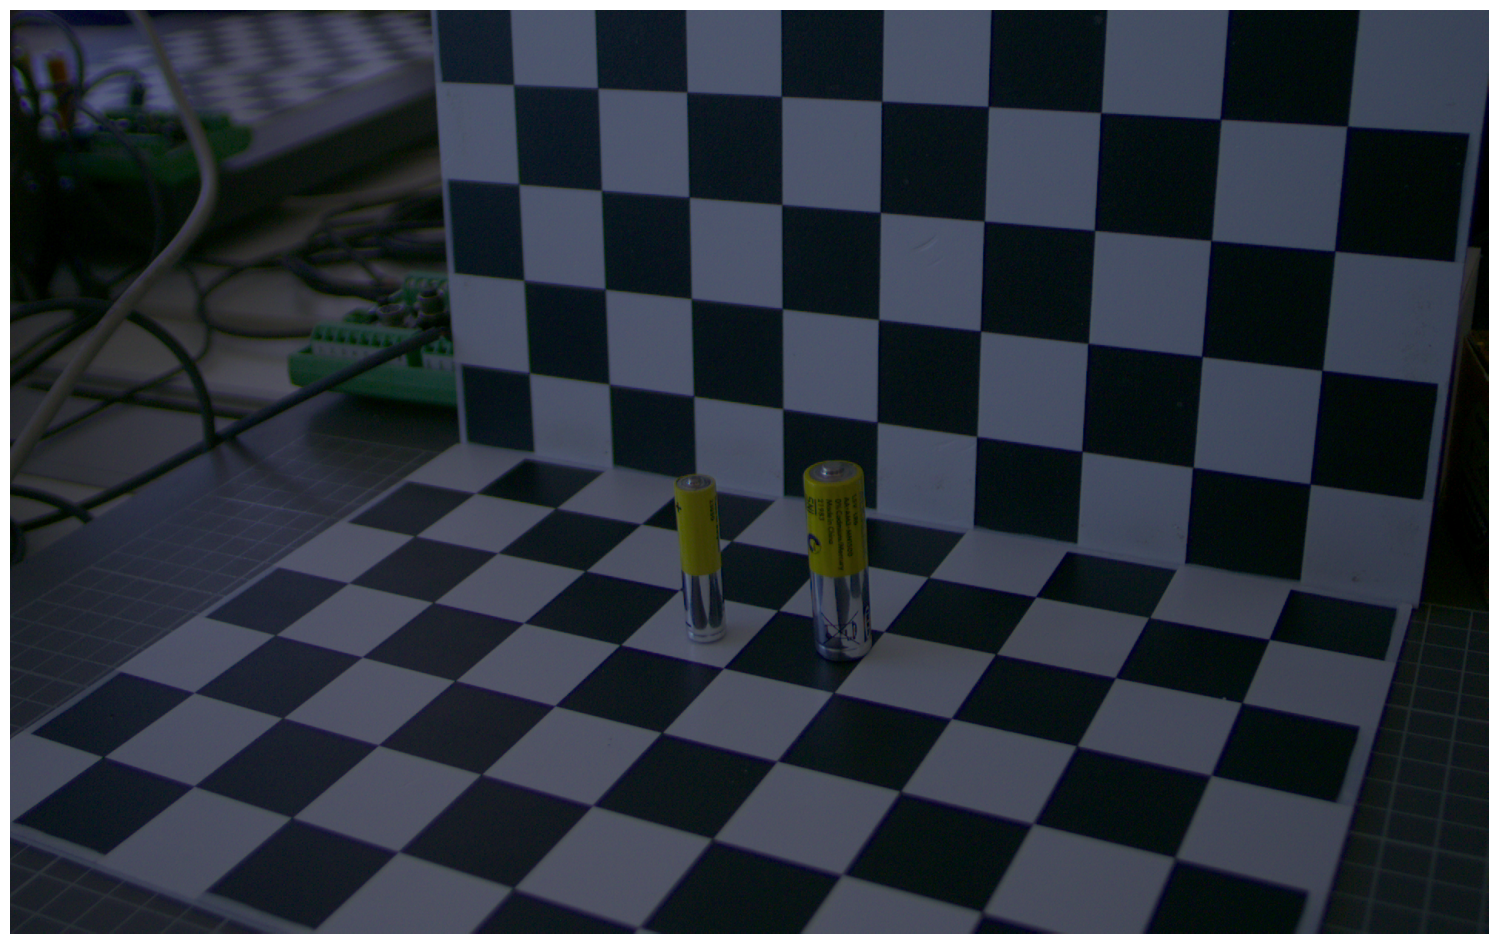

In [4]:
img_bgr = load_image("./vyska.bmp") ###
plot_images(img_bgr)

In [5]:
img_bgr.shape

(1200, 1920, 3)

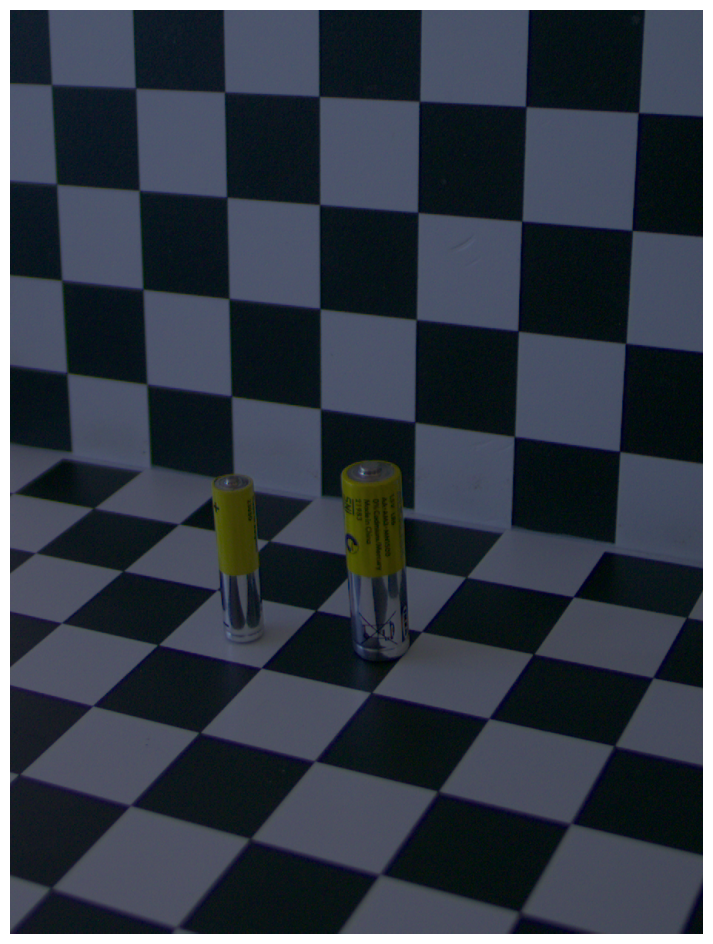

In [6]:
img = crop(img_bgr, 600,0, 1500, 1920)
plot_images(img)

#### 3) Transformujte obrázek z BGR do RGB a získejte souřadnice úběžníků

vp1 = [191.05855999169432, -6.218511835976102, -0.06081161464957208]


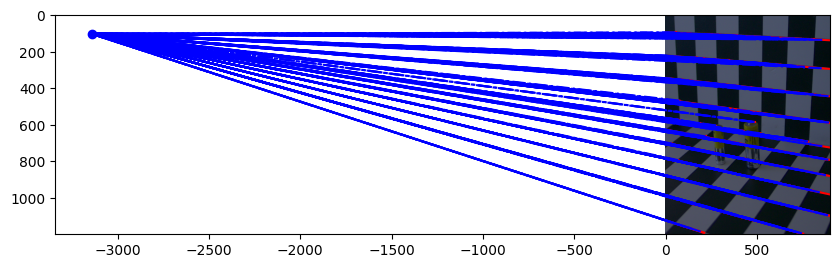

vp2 = [111.02011578478778, -41.48320986713259, 0.062284848389508096]


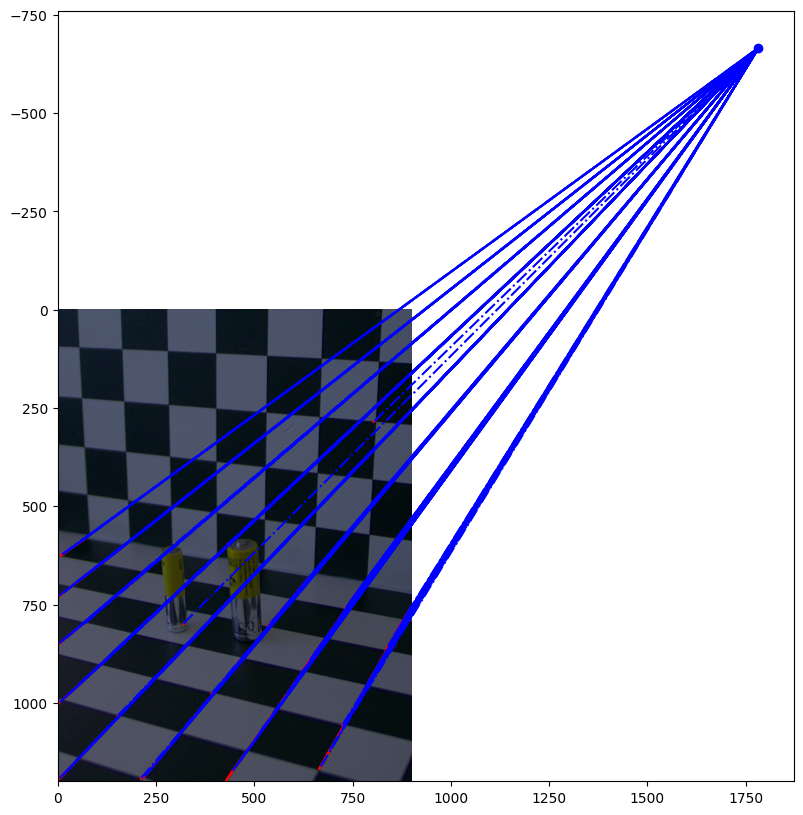

vp3 = [21.085806283166566, 492.58248989941717, 0.03224129401095805]


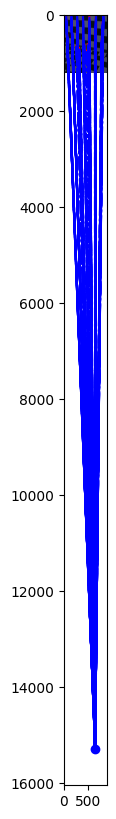

In [7]:
# Funkce compute_vanishing_points vykresluje obrázky pomocí knihovny matplotlib,
# která očekává kanály v pořadí RGB a ne BGR jako OpenCV
img_rgb = cv2.cvtColor(img, code=cv2.COLOR_BGR2RGB) ###
vps = compute_vanishing_points(img_rgb)

**POZOR:** Vypočítané úběžníky nemusí nutně být ve správném pořadí! Zkontrolujte, zda `vp1` a `vp2` jsou horizontální úběžníky a `vpz` je úběžník v ose z. V případě, že tomu tak není, zaměňte indexy u `vps` tak, aby tomu tak bylo.

In [8]:
# POZOR! Úběžníky nemusí být ve správném pořadí!
vp1 = vps[0]
vp2 = vps[1]
vpz = vps[2]

#### 4) Zjistěte souřadnice dvojic bodů pro referenční měrení
Vždy se ze dvojice nejdříve volí Tx a následně až Bx. Zvolte celkem 3 dvojice referenčních bodů (ty, pro které máte změřené reálné vzdálenosti) a najděte jejich souřadnice. Referenční body se volí **vždy** v rovině vertikální (viz [úvod](#Perspektiva---měření-výšky-v-obraze)). Následně zvolte 1 dvojici bodů měřených.

In [ ]:
show_images(img)

x = 481, y = 840
x = 470, y = 584
x = 302, y = 822
x = 290, y = 602
x = 622, y = 919
x = 527, y = 538
x = 657, y = 556
x = 663, y = 418
x = 650, y = 671
x = 288, y = 502
x = 404, y = 630
x = 404, y = 519
x = 403, y = 387
x = 302, y = 820
x = 302, y = 820
x = 288, y = 605


#### 5) Souřadnice doplňte na správná místa skriptu
`REFERENCE_MEASUREMENTS` jsou referenční dvojice bodů a jejich reálná vzdálenost. `Tx` a `Bx` je dvojice bodů měřených.

In [8]:
# Struktura: Tx x,y; Bx x,y; reálná vzdálenost
# např. ((10, 10), (20, 20), 100)
REFERENCE_MEASUREMENTS = [
    ((655, 555), (651, 672), 30), ###
    ((402, 389), (405, 633), 60), ###
    ((168, 236), (184, 590), 90)  ###
]

# Dvojice měřených bodů objektů z obrazu
Tx = (468, 585) ###
Bx = (489, 844) ###


#### 6) Využijte algoritmus pro výpočet odhadu výšky měřeného objektu

In [9]:
# Horizont
vl = np.cross(vp1, vp2)

# Vytvoření objektu pro výpočet odhadu výšky objektu a zavolání funkce
height_estimator = HeightEstimator(REFERENCE_MEASUREMENTS, vl, vpz)
height = abs(height_estimator.calc_height(Tx, Bx))

# Výstup
print('Objekt {:.2f} mm'.format(height))

Objekt 49.73 mm


---
#### 7*) Dobrovolná úloha za 1 bod aktivity
Upravte výše uvedené tak, abyste vypočítali výšku lidí z obrazu `test.jpg`. Pro kontrolu je reálná výška zobrazena na obrázku výše.

In [10]:
img_bgr = load_image('data/test.jpg') ###

show_images(img_bgr)

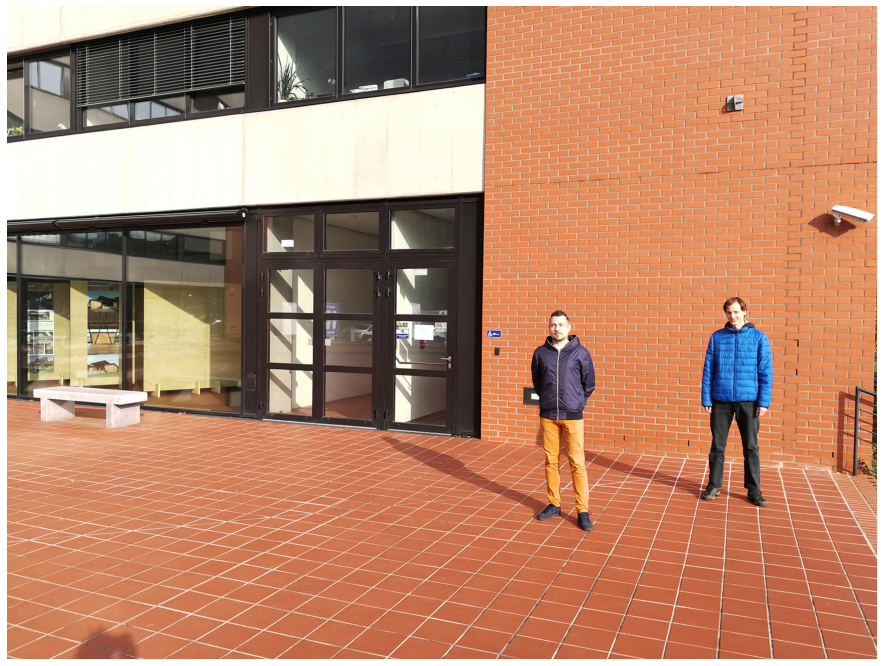

In [11]:
img_bgr.shape
img = img_bgr
plot_images(img)

vp1 = [-239.35528468209424, 38.51694236263587, 0.07974522228289]


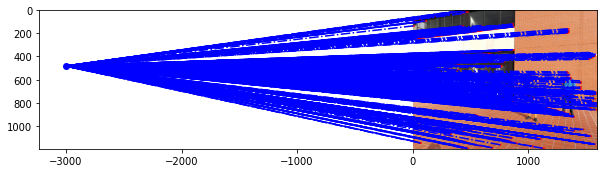

vp2 = [-34.913942083805125, 632.7152557782699, -0.03331483023263848]


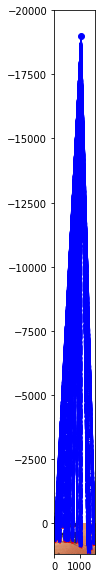

vp3 = [1328.1878713580872, 555.366672675956, 0.973989271808396]


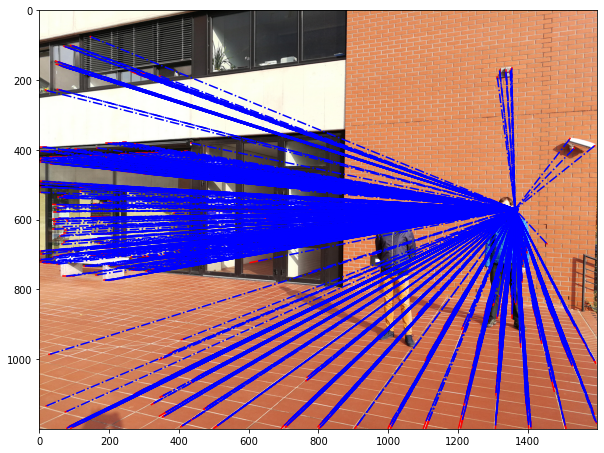

In [12]:
img_rgb = cv2.cvtColor(img, code=cv2.COLOR_BGR2RGB) ###
vps = compute_vanishing_points(img_rgb)

In [13]:
vp1 = vps[0]
vp2 = vps[2]
vpz = vps[1]

In [14]:
show_images(img)

In [15]:
REFERENCE_MEASUREMENTS = [
    ((907, 609), (904, 801), 1390), ###
    ((906, 597), (903, 800), 1490) ###  ###
]

# Dvojice měřených bodů objektů z obrazu
Tx = (1014, 559) ###
Bx = (1023, 938) ###

In [16]:
vl = np.cross(vp1, vp2)

# Vytvoření objektu pro výpočet odhadu výšky objektu a zavolání funkce
height_estimator = HeightEstimator(REFERENCE_MEASUREMENTS, vl, vpz)
height = abs(height_estimator.calc_height(Tx, Bx))

# Výstup
print('Objekt {:.2f} mm'.format(height))

Objekt 1736.75 mm


In [17]:
Tx = (1340, 535) ###
Bx = (1325, 908) ###

In [18]:
vl = np.cross(vp1, vp2)

# Vytvoření objektu pro výpočet odhadu výšky objektu a zavolání funkce
height_estimator = HeightEstimator(REFERENCE_MEASUREMENTS, vl, vpz)
height = abs(height_estimator.calc_height(Tx, Bx))

# Výstup
print('Objekt {:.2f} mm'.format(height))

Objekt 1962.99 mm
